# BrowseComp-Plus replicate benchmark visualizer

Recursively load every `results.jsonl` under a chosen directory, aggregate by `(prompt_type, baseline, trial)`, and summarize accuracy and cost metrics.

- **Dependencies:** `pandas`, `matplotlib` — e.g. `uv pip install pandas matplotlib`
- **Working directory:** run from the `rlm` repo root, from `bench_BrowseComp-Plus`, or from any subdirectory under the repo (the config cell walks up to find the root that contains `bench_BrowseComp-Plus`). Override with `REPO_ROOT` if needed.
- **JSONL:** use JSON booleans `true` / `false` (not Python `True` / `False`).

In [8]:
from __future__ import annotations

from pathlib import Path


def resolve_repo_root() -> Path:
    """Find the repo root as the nearest ancestor of cwd that contains bench_BrowseComp-Plus."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "bench_BrowseComp-Plus").is_dir():
            return p
    raise RuntimeError(
        "Could not find a directory containing bench_BrowseComp-Plus starting from "
        f"{here}. Set REPO_ROOT manually to your rlm clone root."
    )


REPO_ROOT = resolve_repo_root()

BENCHMARK_ROOT = REPO_ROOT / "bench_BrowseComp-Plus" / "replicate_rlm_benchmarks"
PROMPT_TYPE_DEFAULT = "default"
EXPECTED_QUERIES_PER_GROUP = 50

In [9]:
import json
import warnings

import pandas as pd


def _prompt_type_for_row(row: dict, default: str) -> str:
    raw = row.get("prompt_type")
    if raw is None:
        return default
    if isinstance(raw, str) and not raw.strip():
        return default
    return str(raw)


def _baseline_from_results_path(results_jsonl: Path, json_baseline) -> str:
    """Depth2 runs often log the same baseline string as non-depth2; use the results folder name."""
    parent_name = results_jsonl.parent.name
    if parent_name.endswith("_depth2"):
        return parent_name
    if json_baseline is None:
        return ""
    return str(json_baseline)


def discover_results_jsonl(root: Path) -> list[Path]:
    if not root.is_dir():
        raise NotADirectoryError(f"Not a directory: {root}")
    return sorted(root.rglob("results.jsonl"))


def load_benchmark_jsonl(
    root: Path,
    *,
    prompt_type_default: str,
) -> pd.DataFrame:
    paths = discover_results_jsonl(root)
    if not paths:
        raise FileNotFoundError(f"No results.jsonl under {root}")
    rows: list[dict] = []
    for path in paths:
        text = path.read_text(encoding="utf-8")
        for lineno, line in enumerate(text.splitlines(), start=1):
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError as e:
                raise ValueError(
                    f"Invalid JSON in {path} line {lineno}: {e.msg}\n"
                    f"Use JSON booleans true/false and null (not Python True/False/None)."
                ) from e
            if not isinstance(obj, dict):
                raise TypeError(f"Expected object per line in {path} line {lineno}")
            obj = dict(obj)
            obj["baseline"] = _baseline_from_results_path(path, obj.get("baseline"))
            obj["prompt_type"] = _prompt_type_for_row(obj, prompt_type_default)
            obj["source_file"] = str(path)
            rows.append(obj)
    return pd.DataFrame(rows)


df_raw = load_benchmark_jsonl(
    BENCHMARK_ROOT,
    prompt_type_default=PROMPT_TYPE_DEFAULT,
)
df_raw.head(2)

,task_id,query,baseline,trial,ground_truth,response,subagent_calls_mini,subagent_calls_nano,total_time,input_tokens,success,format_error,prompt_type,source_file
0,769,Please tell me the name of the learning instit...,flagship-root_mini-sub,1,Queen Arwa University,Queen Arwa University,0,0,21.964442,49697,True,False,default,/Users/dannyyu/Desktop/rlm/bench_BrowseComp-Pl...
1,770,Could you provide the name of the individual w...,flagship-root_mini-sub,1,Laura Lojo-Rodriguez,"""Awaiting REPL output from the inspection step...",0,0,4.995310,2907,False,True,default,/Users/dannyyu/Desktop/rlm/bench_BrowseComp-Pl...


In [11]:
for col in ("subagent_calls_mini", "subagent_calls_nano"):
    if col not in df_raw.columns:
        raise KeyError(f"Missing required column {col!r} in loaded data")

df = df_raw.copy()
if "trial" not in df.columns:
    df["trial"] = 1
df["trial"] = pd.to_numeric(df["trial"], errors="raise").astype(int)

df["subagent_calls_total"] = df["subagent_calls_mini"].fillna(0) + df[
    "subagent_calls_nano"
].fillna(0)

if "format_error" not in df.columns:
    df["format_error"] = False
else:
    df["format_error"] = df["format_error"].fillna(False).astype(bool)

df["success"] = df["success"].fillna(False).astype(bool)
# Wrong answer / reasoning failure (not a format or protocol error)
df["model_error"] = (~df["success"]) & (~df["format_error"])

df["_no_format_error"] = ~df["format_error"]
df["_success_no_format_error"] = df["success"] & df["_no_format_error"]

group_cols = ["prompt_type", "baseline", "trial"]
summary = (
    df.groupby(group_cols, dropna=False)
    .agg(
        success_rate=("success", "mean"),
        avg_time_sec=("total_time", "mean"),
        avg_input_token=("input_tokens", "mean"),
        total_subagent_calls=("subagent_calls_total", "sum"),
        n_queries=("task_id", "count"),
        n_format_errors=("format_error", "sum"),
        n_model_errors=("model_error", "sum"),
        _denom_no_fmt=("_no_format_error", "sum"),
        _num_succ_no_fmt=("_success_no_format_error", "sum"),
    )
    .reset_index()
    .sort_values(["baseline", "trial"], kind="stable")
)

_denom = summary["_denom_no_fmt"].astype(float)
_num = summary["_num_succ_no_fmt"].astype(float)
summary["norm_success_rate"] = (_num / _denom.where(_denom > 0)).astype(float)
summary = summary.drop(columns=["_denom_no_fmt", "_num_succ_no_fmt"])

summary = summary[
    [
        #"prompt_type",
        "baseline",
        "trial",
        "success_rate",
        "norm_success_rate",
        "n_format_errors",
        "n_model_errors",        
        "avg_time_sec",
        "avg_input_token",
        "total_subagent_calls",
        "n_queries",
    ]
]

bad_n = summary[summary["n_queries"] != EXPECTED_QUERIES_PER_GROUP]
if len(bad_n):
    for _, r in bad_n.iterrows():
        warnings.warn(
            f"Expected {EXPECTED_QUERIES_PER_GROUP} queries for "
            f"prompt_type={r['prompt_type']!r} baseline={r['baseline']!r} trial={r['trial']!r}, "
            f"got n_queries={int(r['n_queries'])}",
            stacklevel=1,
        )

summary

,baseline,trial,success_rate,norm_success_rate,n_format_errors,n_model_errors,avg_time_sec,avg_input_token,total_subagent_calls,n_queries
0,flagship-root_mini-sub,1,0.64,0.888889,14,4,36.884722,251986.28,0,50
1,flagship-root_mini-sub,2,0.54,0.794118,16,7,34.948139,167131.38,0,50
2,flagship-root_mini-sub_depth2,1,0.58,0.763158,12,9,67.165031,165844.44,142,50
3,flagship-root_mini-sub_gpt5,1,0.88,0.880000,0,6,273.661182,154810.36,87,50
4,flagship-root_nano-sub,1,0.56,0.848485,17,5,33.857603,166403.02,0,50
5,mini-root_mini-sub,1,0.58,0.580000,0,21,31.178180,353855.38,0,50
6,mini-root_mini-sub,2,0.82,0.820000,0,9,31.763165,350705.42,0,50
7,mini-root_mini-sub_depth2,1,0.50,0.500000,0,25,77.968265,316767.48,319,50
8,mini-root_nano-sub,1,0.68,0.680000,0,16,33.042369,421827.42,0,50


In [7]:
from IPython.display import display

display_cols = [
    "prompt_type",
    "baseline",
    "trial",
    "success_rate", 
    "norm_success_rate",
    "n_format_errors",
    "n_model_errors",
    "avg_time_sec",
    "avg_input_token",
    "total_subagent_calls",
    "n_queries",
]
display(summary[display_cols])

KeyError: "['norm_success_rate'] not in index"

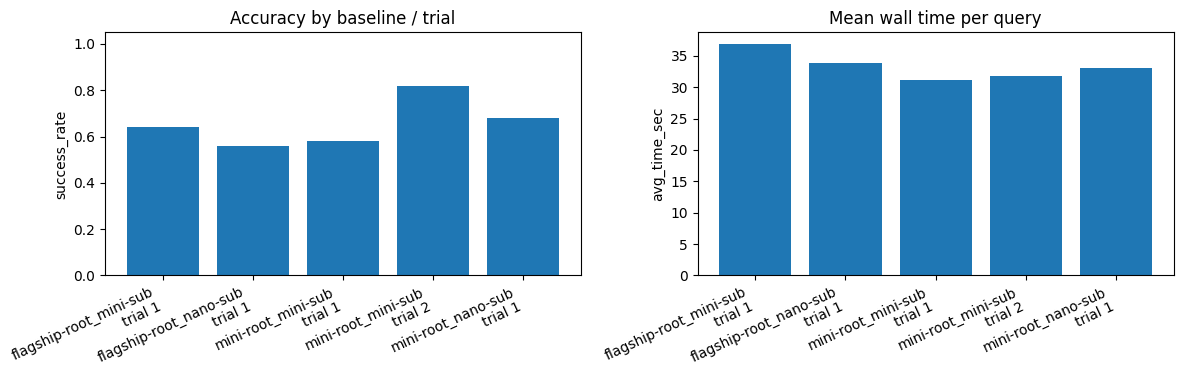

In [10]:
import matplotlib.pyplot as plt

labels = [
    f"{row.baseline}\ntrial {row.trial}" for row in summary.itertuples(index=False)
]
x = range(len(summary))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax0 = axes[0]
ax0.bar(x, summary["success_rate"].to_numpy())
ax0.set_xticks(list(x))
ax0.set_xticklabels(labels, rotation=25, ha="right")
ax0.set_ylabel("success_rate")
ax0.set_ylim(0, 1.05)
ax0.set_title("Accuracy by baseline / trial")

ax1 = axes[1]
ax1.bar(x, summary["avg_time_sec"].to_numpy())
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=25, ha="right")
ax1.set_ylabel("avg_time_sec")
ax1.set_title("Mean wall time per query")

fig.tight_layout()
plt.show()